# Global Events, Commodities and Currency Markets — Part I
### Data Analytics Component — code used to generate all figures and tables

This notebook reproduces every **table (1–12)** and **figure (1–7)** in the report.
Run the cells top to bottom. Set `DATA_DIR` below to the folder holding the four CSV files:

- `Brent_Oil.csv`
- `Gold_100years.csv`
- `silver_100_years.csv`
- `swift_currency_tracker_all_reports.csv`


## 0 · Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
pd.set_option('display.max_rows', 120)
plt.rcParams.update({'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.3})

DATA_DIR = '.'   # <- folder containing the four CSV files

# Colours used throughout the report
GOLD, SIL, OIL, NAVY, RED = '#c9a227', '#7f8c8d', '#2c6e49', '#1f3a5f', '#b3242b'

## A · Data Preparation & Understanding

### Q4 · Load and clean the commodity datasets
Dates are stored as text in `MM/DD/YYYY`. We parse them to real dates and derive **Month** and **Year** columns.

In [2]:
def load_commodity(filename):
    df = pd.read_csv(f'{DATA_DIR}/{filename}')
    df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')   # Q4: text -> date
    df['Month'] = df['Date'].dt.month                            # Q4: derived
    df['Year'] = df['Date'].dt.year                              # Q4: derived
    return df.sort_values('Date').reset_index(drop=True)

brent  = load_commodity('Brent_Oil.csv')
gold   = load_commodity('Gold_100years.csv')
silver = load_commodity('silver_100_years.csv')

swift = pd.read_csv(f'{DATA_DIR}/swift_currency_tracker_all_reports.csv')
swift['data_month_date'] = pd.to_datetime(swift['data_month'], format='%B %Y')

brent.head()

,Date,Value,Month,Year
0,1946-01-01,21.23,1,1946
1,1946-02-01,21.35,2,1946
2,1946-03-01,21.11,3,1946
3,1946-04-01,22.79,4,1946
4,1946-05-01,22.67,5,1946


### Table 1 · Q1–Q3 — Coverage, size and data quality

In [3]:
rows = []
for name, df in [('Brent Oil', brent), ('Gold', gold), ('Silver', silver)]:
    rows.append({
        'Dataset': name,
        'Start': df['Date'].min().strftime('%b %Y'),
        'End': df['Date'].max().strftime('%b %Y'),
        'Rows': len(df),
        'Missing values': int(df['Value'].isna().sum()),
        'Duplicate dates': int(df['Date'].duplicated().sum()),
    })
rows.append({
    'Dataset': 'SWIFT Currency Tracker',
    'Start': swift['data_month_date'].min().strftime('%b %Y'),
    'End': swift['data_month_date'].max().strftime('%b %Y'),
    'Rows': len(swift),
    'Missing values': int(swift['value'].isna().sum()),
    'Duplicate dates': 'n/a (long format)',
})
table1 = pd.DataFrame(rows)
table1

,Dataset,Start,End,Rows,Missing values,Duplicate dates
0,Brent Oil,Jan 1946,Mar 2026,963,0,0
1,Gold,Jan 1915,Apr 2026,1336,0,0
2,Silver,Jan 1915,Apr 2026,1336,0,0
3,SWIFT Currency Tracker,Dec 2025,Mar 2026,330,42,n/a (long format)


### Table 2 · Q5 — Main metrics in the SWIFT Currency Tracker

In [4]:
table2 = (swift.groupby(['metric', 'category']).size()
          .reset_index(name='Rows')
          .sort_values('Rows', ascending=False)
          .rename(columns={'metric': 'Metric', 'category': 'Category'})
          .reset_index(drop=True))
table2

,Metric,Category,Rows
0,Global Payment Share,Currency Ranking,80
1,International Payment Share (ex-Eurozone),Currency Ranking,80
2,Offshore RMB by Economy,Offshore Economies,60
3,FX Spot Currency Ranking,FX Spot,40
4,Trade Finance Share,Currency Ranking,40
5,FX Spot Economies (RMB),Offshore Economies,24
6,RMB MoM Payment Growth,RMB Activity,4
7,All Currencies MoM Payment Growth,Market Activity,2


## B · Descriptive Analytics

### Table 3 · Q6–Q8 — Highest and lowest prices

In [5]:
def hi_lo(df):
    hi, lo = df.loc[df['Value'].idxmax()], df.loc[df['Value'].idxmin()]
    return round(hi['Value'], 2), int(hi['Year']), round(lo['Value'], 2), int(lo['Year'])

table3 = pd.DataFrame(
    [[f'{n} ({u})', *hi_lo(df)] for n, u, df in
     [('Brent Oil', 'USD/bbl', brent), ('Gold', 'USD/oz', gold), ('Silver', 'USD/oz', silver)]],
    columns=['Commodity', 'Highest', 'Year (high)', 'Lowest', 'Year (low)'])
table3

,Commodity,Highest,Year (high),Lowest,Year (low)
0,Brent Oil (USD/bbl),211.21,2008,21.11,1946
1,Gold (USD/oz),5277.89,2026,19.25,1915
2,Silver (USD/oz),113.95,2026,0.28,1932


### Table 4 · Q9 — Average price by year (most recent 13 years shown)

In [6]:
brent_annual  = brent.groupby('Year')['Value'].mean().round(2)
gold_annual   = gold.groupby('Year')['Value'].mean().round(2)
silver_annual = silver.groupby('Year')['Value'].mean().round(2)

annual = pd.concat([brent_annual, gold_annual, silver_annual], axis=1)
annual.columns = ['Brent (USD/bbl)', 'Gold (USD/oz)', 'Silver (USD/oz)']
table4 = annual.loc[2014:].reset_index()   # recent slice shown in the report
table4

,Year,Brent (USD/bbl),Gold (USD/oz),Silver (USD/oz)
0,2014,127.67,1256.25,18.76
1,2015,68.52,1151.95,15.51
2,2016,60.79,1249.98,17.13
3,2017,69.85,1269.34,17.24
4,2018,84.91,1265.60,15.64
5,2019,74.03,1405.32,16.36
6,2020,49.19,1784.66,20.80
7,2021,83.02,1792.73,24.97
8,2022,106.45,1798.96,21.67
9,2023,84.19,1953.69,23.58


### Table 5 · Q10–Q12 — Top five years by average price

In [7]:
def top5(s):
    return [f'{int(y)} — {v:,.2f}' for y, v in s.sort_values(ascending=False).head(5).items()]

table5 = pd.DataFrame({
    'Brent Oil': top5(brent_annual),
    'Gold': top5(gold_annual),
    'Silver': top5(silver_annual),
})
table5

,Brent Oil,Gold,Silver
0,2008 — 150.96,"2026 — 4,881.62",2026 — 96.08
1,1980 — 149.86,"2025 — 3,472.54",2025 — 41.50
2,2011 — 142.12,"2024 — 2,404.58",2011 — 35.56
3,2013 — 138.30,"2023 — 1,953.69",2012 — 31.63
4,2012 — 135.27,"2022 — 1,798.96",2024 — 28.13


## C · Trend & Visual Analytics

### Figure 1 · Q13 — Brent Oil price over time

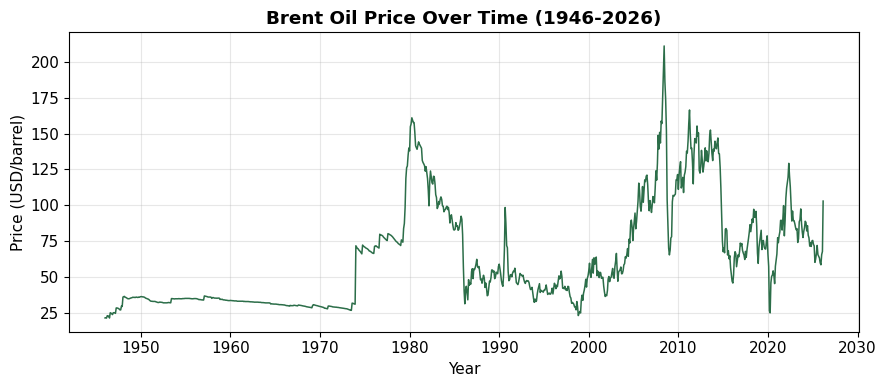

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(brent['Date'], brent['Value'], color=OIL, lw=1.1)
ax.set_title('Brent Oil Price Over Time (1946-2026)', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Price (USD/barrel)')
fig.tight_layout()
# fig.savefig('figure1_brent.png', dpi=130)
plt.show()

### Figure 2 · Q14 — Gold price over time

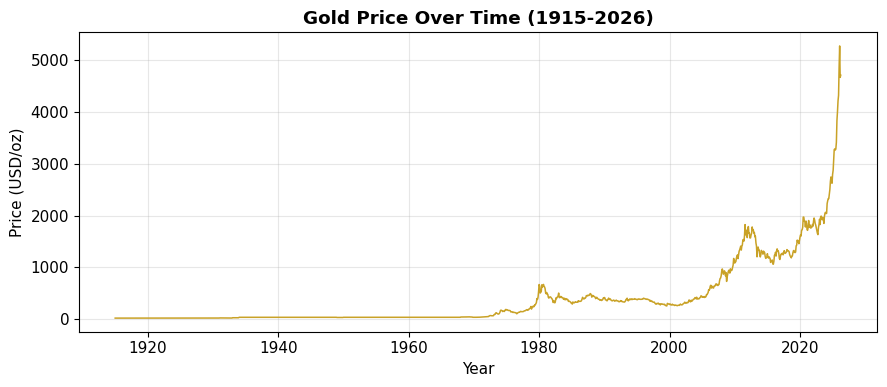

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(gold['Date'], gold['Value'], color=GOLD, lw=1.1)
ax.set_title('Gold Price Over Time (1915-2026)', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Price (USD/oz)')
fig.tight_layout()
plt.show()

### Figure 3 · Q15 — Silver price over time

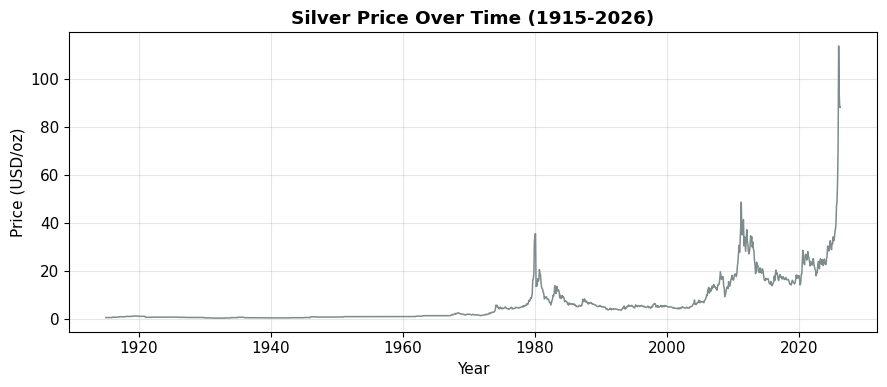

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(silver['Date'], silver['Value'], color=SIL, lw=1.1)
ax.set_title('Silver Price Over Time (1915-2026)', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Price (USD/oz)')
fig.tight_layout()
plt.show()

### Figure 4 · Q16 — Combined Gold & Silver trend (dual axis)

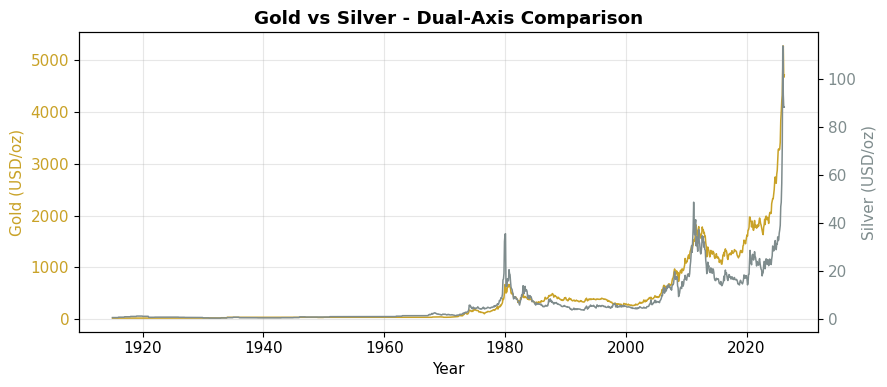

In [11]:
fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(gold['Date'], gold['Value'], color=GOLD, lw=1.1)
ax1.set_ylabel('Gold (USD/oz)', color=GOLD); ax1.tick_params(axis='y', labelcolor=GOLD)
ax1.set_xlabel('Year')

ax2 = ax1.twinx(); ax2.grid(False)
ax2.plot(silver['Date'], silver['Value'], color=SIL, lw=1.1)
ax2.set_ylabel('Silver (USD/oz)', color=SIL); ax2.tick_params(axis='y', labelcolor=SIL)

ax1.set_title('Gold vs Silver - Dual-Axis Comparison', fontweight='bold')
fig.tight_layout()
plt.show()

### Figure 5 · Q17 — Average annual Brent Oil price, last 10 years

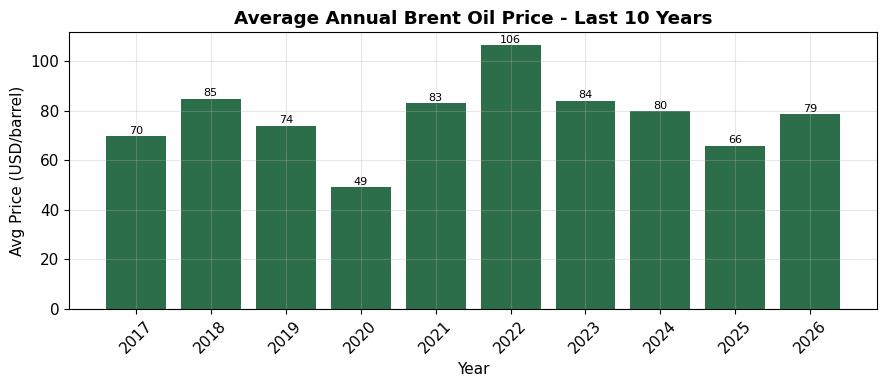

In [12]:
last10 = brent_annual.tail(10)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(last10.index.astype(str), last10.values, color=OIL)
ax.set_title('Average Annual Brent Oil Price - Last 10 Years', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Avg Price (USD/barrel)')
for i, v in enumerate(last10.values):
    ax.text(i, v + 1, f'{v:.0f}', ha='center', fontsize=8)
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

### Table 6 · Q18 — Latest available value

In [13]:
def latest_row(name, unit, df):
    r = df.iloc[-1]
    return {'Commodity': name, 'Latest date': r['Date'].strftime('%b %Y'),
            'Latest value': f"{r['Value']:,.2f} {unit}"}

table6 = pd.DataFrame([latest_row('Brent Oil', 'USD/bbl', brent),
                       latest_row('Gold', 'USD/oz', gold),
                       latest_row('Silver', 'USD/oz', silver)])
table6

,Commodity,Latest date,Latest value
0,Brent Oil,Mar 2026,102.86 USD/bbl
1,Gold,Apr 2026,"4,712.89 USD/oz"
2,Silver,Apr 2026,88.36 USD/oz


## D · Currency Tracker Analytics

We work with the most recent **Global Payment Share** report month.

In [14]:
gps = swift[swift['metric'] == 'Global Payment Share'].copy()
latest_gps_month = gps['data_month_date'].max()
latest_gps = (gps[gps['data_month_date'] == latest_gps_month]
              .sort_values('value', ascending=False).reset_index(drop=True))
print('Most recent Global Payment Share month:', latest_gps_month.strftime('%B %Y'))

Most recent Global Payment Share month: March 2026


### Table 7 · Q19 — Top currencies by global payment share (latest month)

In [15]:
table7 = (latest_gps.head(8)[['currency_or_economy', 'value']]
          .rename(columns={'currency_or_economy': 'Currency', 'value': 'Global payment share (%)'}))
table7.insert(0, 'Rank', range(1, len(table7) + 1))
table7

,Rank,Currency,Global payment share (%)
0,1,USD,51.14
1,2,EUR,21.30
2,3,GBP,6.54
3,4,JPY,3.53
4,5,CNY,3.10
5,6,CAD,3.03
6,7,HKD,1.76
7,8,AUD,1.61


### Q20 & Q21 — USD share, and CNY/RMB share + rank

In [16]:
usd_share = latest_gps.loc[latest_gps['currency_or_economy'] == 'USD', 'value'].iloc[0]
cny_row = latest_gps[latest_gps['currency_or_economy'] == 'CNY'].iloc[0]
cny_rank = int(cny_row['rmb_global_rank'])

print(f"Q20 — USD share: {usd_share:.2f}%")
print(f"Q21 — CNY/RMB share: {cny_row['value']:.2f}%, rank {cny_rank}")

Q20 — USD share: 51.14%
Q21 — CNY/RMB share: 3.10%, rank 5


### Table 8 · Q22 — Currencies most often in the top five

In [17]:
counts = {}
for _, grp in gps.groupby('data_month_date'):
    for cur in grp.sort_values('value', ascending=False).head(5)['currency_or_economy']:
        counts[cur] = counts.get(cur, 0) + 1
n_reports = gps['data_month_date'].nunique()

table8 = (pd.DataFrame(sorted(counts.items(), key=lambda x: -x[1]),
                       columns=['Currency', 'Times in top 5'])
          .assign(**{'Reports covered': lambda d: d['Times in top 5'].astype(str) + f' of {n_reports}'}))
table8

,Currency,Times in top 5,Reports covered
0,USD,4,4 of 4
1,EUR,4,4 of 4
2,GBP,4,4 of 4
3,JPY,4,4 of 4
4,CAD,2,2 of 4
5,CNY,2,2 of 4


### Q23 — Highest-share offshore RMB economy

In [18]:
off = swift[swift['metric'] == 'Offshore RMB by Economy'].copy()
off_latest = off[off['data_month_date'] == off['data_month_date'].max()].sort_values('value', ascending=False)
top_off = off_latest.iloc[0]
print(f"Q23 — {top_off['currency_or_economy']} = {top_off['value']:.2f}% "
      f"({off['data_month_date'].max().strftime('%B %Y')})")
off_latest[['currency_or_economy', 'value']].head(6).reset_index(drop=True)

Q23 — Hong Kong = 75.23% (March 2026)


,currency_or_economy,value
0,Hong Kong,75.23
1,United Kingdom,6.90
2,Singapore,4.37
3,United States,2.81
4,France,1.80
5,Taiwan,1.34


### Figure 6 · Q24 — Top 10 currencies by global payment share (selected month)

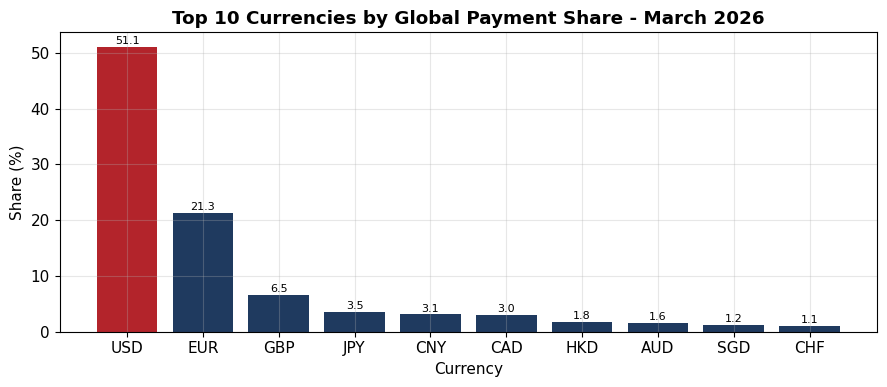

In [19]:
top10 = latest_gps.head(10)
labels, vals = top10['currency_or_economy'].tolist(), top10['value'].tolist()
colors = [RED if l == 'USD' else NAVY for l in labels]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(labels, vals, color=colors)
ax.set_title(f"Top 10 Currencies by Global Payment Share - {latest_gps_month.strftime('%B %Y')}",
             fontweight='bold')
ax.set_xlabel('Currency'); ax.set_ylabel('Share (%)')
for i, v in enumerate(vals):
    ax.text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=8)
fig.tight_layout()
plt.show()

## E · Simple Comparison Questions

### Table 9 · Q25 — Latest Gold value vs long-term average

In [20]:
def vs_average(df):
    latest = df.iloc[-1]['Value']; avg = df['Value'].mean()
    pos = 'Above average' if latest > avg else 'Below average'
    return pd.DataFrame([{'Latest value': round(latest, 2),
                          'Full-series average': round(avg, 2),
                          'Position': pos}])

table9 = vs_average(gold)
table9

,Latest value,Full-series average,Position
0,4712.89,397.55,Above average


### Table 10 · Q26 — Latest Brent Oil value vs long-term average

In [21]:
table10 = vs_average(brent)
table10

,Latest value,Full-series average,Position
0,102.86,62.71,Above average


### Table 11 · Q27 — Largest price swings

In [22]:
def cov(annual_series):
    return round(annual_series.std() / annual_series.mean() * 100, 1)

def monthly_vol(df):
    return round(df['Value'].pct_change().dropna().std() * 100, 1)

table11 = pd.DataFrame([
    ['Brent Oil', cov(brent_annual),  monthly_vol(brent)],
    ['Gold',      cov(gold_annual),   monthly_vol(gold)],
    ['Silver',    cov(silver_annual), monthly_vol(silver)],
], columns=['Commodity', 'Variation in annual avg (CoV %)', 'Monthly return volatility (%)'])
table11

,Commodity,Variation in annual avg (CoV %),Monthly return volatility (%)
0,Brent Oil,55.6,9.1
1,Gold,173.4,4.3
2,Silver,171.4,7.7


### Table 12 · Q28 — A strong oil year (2008): did metals move too?

In [23]:
def yearly_avg(df, y):
    return round(df[df['Year'] == y]['Value'].mean(), 2)

table12 = pd.DataFrame([
    {'Year': y,
     'Brent (avg)': yearly_avg(brent, y),
     'Gold (avg)': yearly_avg(gold, y),
     'Silver (avg)': yearly_avg(silver, y)}
    for y in [2007, 2008, 2009]])
table12

,Year,Brent (avg),Gold (avg),Silver (avg)
0,2007,119.10,704.68,13.51
1,2008,150.96,880.21,14.98
2,2009,98.01,982.65,14.77


### Figure 7 · Q29 — Summary dashboard (4 visuals)

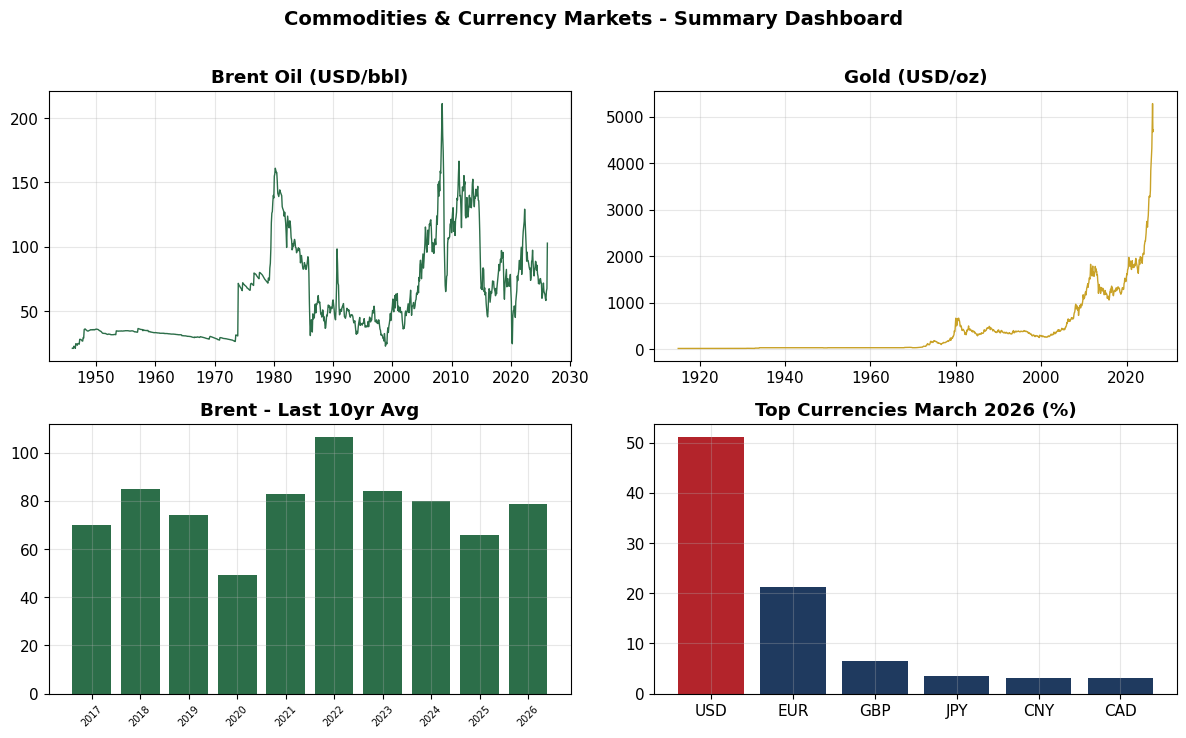

In [24]:
fig, axs = plt.subplots(2, 2, figsize=(12, 7.5))

axs[0, 0].plot(brent['Date'], brent['Value'], color=OIL, lw=1)
axs[0, 0].set_title('Brent Oil (USD/bbl)', fontweight='bold')

axs[0, 1].plot(gold['Date'], gold['Value'], color=GOLD, lw=1)
axs[0, 1].set_title('Gold (USD/oz)', fontweight='bold')

axs[1, 0].bar(last10.index.astype(str), last10.values, color=OIL)
axs[1, 0].set_title('Brent - Last 10yr Avg', fontweight='bold')
axs[1, 0].tick_params(axis='x', rotation=45, labelsize=7)

axs[1, 1].bar(labels[:6], vals[:6], color=[RED if l == 'USD' else NAVY for l in labels[:6]])
axs[1, 1].set_title(f'Top Currencies {latest_gps_month.strftime("%B %Y")} (%)', fontweight='bold')

for ax in axs.flat:
    ax.grid(alpha=0.3)
fig.suptitle('Commodities & Currency Markets - Summary Dashboard', fontsize=14, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### Q30 — Three insights for a manager
1. Precious metals are at record highs — gold and silver surged to all-time peaks in 2025–2026.
2. Oil is the most event-sensitive commodity, with the largest short-term price swings of the three.
3. The US Dollar still dominates global payments at about 51%, while the CNY is 5th at roughly 3%.

*Optional:* uncomment the `fig.savefig(...)` lines to export the figures as PNGs.